In [1]:
# Importamos las librerías necesarias de scikit-learn

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [2]:
import sys
import os
import pandas as pd
sys.path.insert(0, os.path.abspath(".."))
from etl import run_etl
from etl import DOMINIOS, DC_LABELS, EDUCATION_LEVEL, DC_LABELS, DC_ORDER

In [3]:
df_tabla_0_imp, df_tabla_1_imp, df = run_etl("../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

🔧  Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida     

In [4]:
DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())

In [6]:
df

,sheet_name,nivel_estudio,dc,orientacion,atencion,lenguaje,memoria_verbal,memoria_visual,gnosias,praxis,ejecutivas,age_num
0,GC1-60,0,0,4.000000,3.250000,3.750000,2.666667,3.000000,3.5,4.0,3.200000,60
1,GC2-62,0,0,4.000000,3.000000,3.750000,2.500000,3.000000,3.5,4.0,3.000000,62
2,F021-72,0,2,4.000000,2.500000,4.000000,2.166667,2.000000,4.0,1.0,1.500000,72
3,S2-F067-53,0,1,4.000000,2.000000,3.000000,2.000000,3.000000,4.0,2.0,2.166667,53
4,GC3-60,0,0,4.000000,3.000000,3.500000,2.666667,3.000000,3.5,4.0,3.142857,60
...,...,...,...,...,...,...,...,...,...,...,...,...
112,S60-F067-72,1,1,3.000000,2.666667,3.333333,3.000000,3.000000,4.0,3.5,3.250000,72
113,S61-F067-75,1,1,2.333333,2.000000,3.000000,3.250000,2.666667,4.0,3.5,2.500000,75
114,F0233-85,1,2,1.000000,2.000000,3.000000,2.750000,2.666667,4.0,2.5,1.500000,85
115,GC29-65,1,0,3.000000,3.000000,3.666667,3.000000,2.666667,4.0,3.5,2.750000,65


In [10]:
# 1. Se definen las caracteristicas predictoras (X) y la variable objetivo (y - categorias clinicas) para el modelo de clasificación.

features = DOMINIOS_COGNITIVOS + ["age_num", "nivel_estudio"]
X = df[features]
y = pd.to_numeric(df["dc"], errors='coerce').fillna(-1).astype(int)

# Se filtran las filas que tengan etiquetas validas (0, 1, 2)
mask = y != -1
X = X[mask]
y = y[mask]

seed = 19971711


# Definir el diccionario de modelos con balanceo de clases algorítmico
# models = {
#     "Regresión Logística": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=seed),
#     # Limitamos la profundidad del Random Forest a 3 para evitar overfitting en el dataset pequeño
#     "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200, min_samples_leaf=5,min_samples_split=10,max_features="sqrt",  max_depth=3, random_state=seed),
#     "SVM (Lineal)": SVC(kernel="linear", probability=True, class_weight="balanced", random_state=seed),
#     "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=seed)
# }

models = {
    "Logistic Regression":
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=seed
        ),

    "Random Forest":
        RandomForestClassifier(
            class_weight="balanced",
            n_estimators=200,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            max_depth=3,
            random_state=seed
        ),

    "SVM Linear":
        SVC(
            kernel="linear",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ),

    "SVM RBF":
        SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', n_jobs=-1),
    "GradientBoostingClassifier": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=seed)
}

# Configurar la validación cruzada estratificada y las métricas recomendadas para datos desbalanceados

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=seed
)

# Se establecen las métricas de evaluación más acordes, teniendo en cuenta que el dataset es pequeño y las clases estan desbalanceadas.
scoring = ['f1_macro', 'balanced_accuracy', 'matthews_corrcoef']

# Resultados
results = []
results_overfitting = []

print("Iniciando entrenamiento y validación cruzada...")
for name, model in models.items():
    
    # Se crea un pipeline que incluye imputación, aunque el conjunto de datos ya esta preprocesado, es una buena práctica para evitar problemas con NaNs en otros conjuntos de datos.
    # Paso 1: Rellenar NaNs con la mediana (SimpleImputer)
    # Paso 2: Escalar los datos a Media=0, Std=1 (StandardScaler)
    # Paso 3: Entrenar el clasificador
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # Validación cruzada con las métricas definidas
    cv_scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()
    
    results_overfitting.append({
        "Modelo": name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Matthews Corr. Coef": cv_scores['test_matthews_corrcoef'].mean(),
        "MCC (Std)": cv_scores['test_matthews_corrcoef'].std()
    })

# Convertir resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("-" * 70)
print("RESULTADOS DE LOS MODELOS (ORDENADOS POR F1-SCORE MACRO)")
print("-" * 70)
display(df_results.round(4))

# Mostrar resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("-" * 85)
print("🔍 ANÁLISIS DE SOBREENTRENAMIENTO (OVERFITTING)")
print("-" * 85)
display(df_overfit.round(4))

Iniciando entrenamiento y validación cruzada...
----------------------------------------------------------------------
RESULTADOS DE LOS MODELOS (ORDENADOS POR F1-SCORE MACRO)
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Matthews Corr. Coef,MCC (Std)
3,SVM RBF,0.7734,0.0783,0.7850,0.0824,0.6484,0.1234
2,SVM Linear,0.7694,0.0838,0.7872,0.0867,0.6477,0.1307
0,Logistic Regression,0.7643,0.0791,0.7790,0.0820,0.6385,0.1246
4,KNeighborsClassifier,0.7594,0.0804,0.7533,0.0854,0.6235,0.1270
1,Random Forest,0.7508,0.0839,0.7805,0.0808,0.6258,0.1276
5,GradientBoostingClassifier,0.7288,0.0971,0.7253,0.0989,0.5796,0.1520


-------------------------------------------------------------------------------------
🔍 ANÁLISIS DE SOBREENTRENAMIENTO (OVERFITTING)
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
3,SVM RBF,0.9158,0.7734,0.1424,0.0783
2,SVM Linear,0.8705,0.7694,0.1012,0.0838
0,Logistic Regression,0.8719,0.7643,0.1076,0.0791
4,KNeighborsClassifier,1.0000,0.7594,0.2406,0.0804
1,Random Forest,0.8585,0.7508,0.1077,0.0839
5,GradientBoostingClassifier,1.0000,0.7288,0.2712,0.0971


ValueError: cross_val_predict only works for partitions

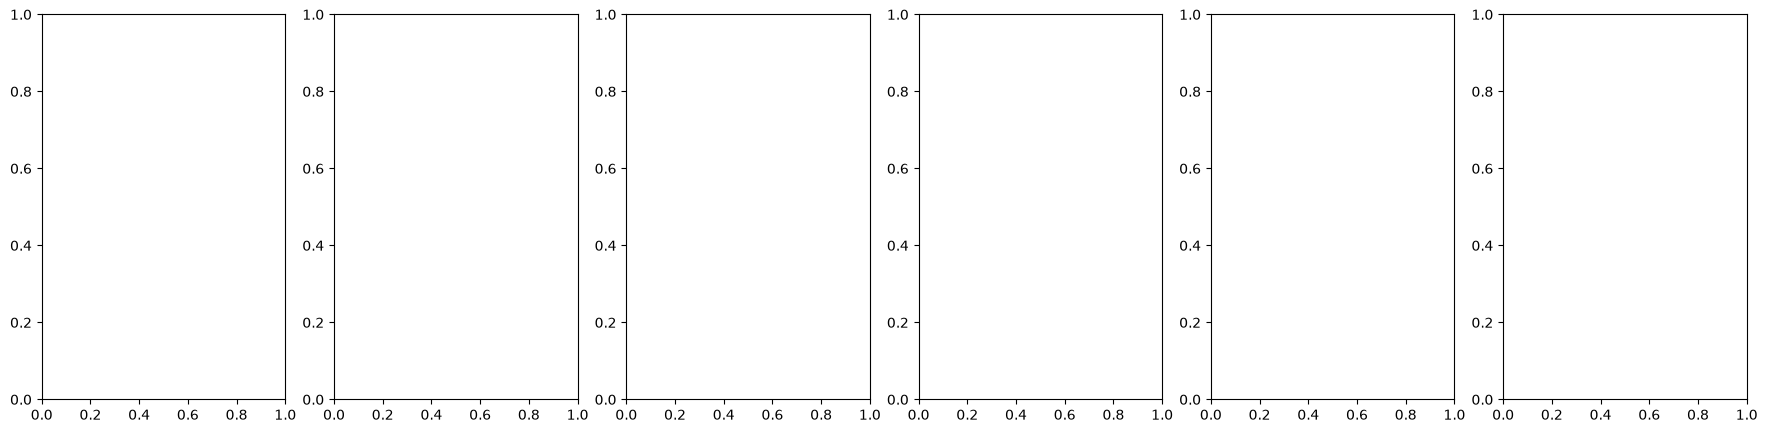

In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Creamos una figura ancha para poner las matrices una al lado de la otra
fig, axes = plt.subplots(1, len(models), figsize=(22, 5))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # Genera predicciones para todo el dataset, pero cada paciente es 
    # evaluado solo cuando su fold fue el "fold de prueba" (sin trampa).
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    
    # Calcula y grafica la matriz
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "DCL", "Demencia"])
    
    # Personalización visual
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Predicción del Modelo", fontsize=11)
    ax.set_ylabel("Diagnóstico Clínico Real", fontsize=11)

plt.tight_layout()
plt.show()
